<a href="https://colab.research.google.com/github/pkorotkow/statprak/blob/main/statprak4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The homework is to prepare a report for the Ministry of Transport, revealing the nature and characteristics of flight delays. The report should help identify problem areas and contribute to decision-making. Therefore, strive not to state general facts, but to show problems. For example, the fact "the average departure delay is 15 minutes" by itself says little and does not help to understand why this is happening. On the contrary, a graph showing that on Mondays delays increase threefold compared to other days against the background of an increase in the number of flights and passengers suggests a possible cause of the problem: airports cannot cope with uneven load.

The report should be in the form of a notebook with a clear structure. At the beginning of the Markdown cell there is a brief description of the question under study (what we will study), then the code and all its outputs (tables, graphs, values), then again in the Markdown cell in which your brief conclusion is formulated.

The report should contain at least 5 results confirmed by graphs. For variety of material, use different types of diagrams. All graphs should be provided with the necessary signatures (axis designations, title, color scheme legend).

To solve the problems, use the methods of the pandas library.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv('flights.csv', low_memory=False, nrows= 100000)
airlines = pd.read_csv('airlines.csv')
airports = pd.read_csv('airports.csv')
df = pd.merge(df, airlines, left_on='AIRLINE', right_on='IATA_CODE', how = 'left')
df.drop('IATA_CODE', axis=1, inplace=True)


# **Исследование 1**
Я хочу посмотреть, как задержки накапливаются в течение суток. То есть может ли быть такое, что к вечеру задержки больше из-за эффекта снежного кома?

Если это подтвердится, значит расписание слишком плотное, что нехорошо

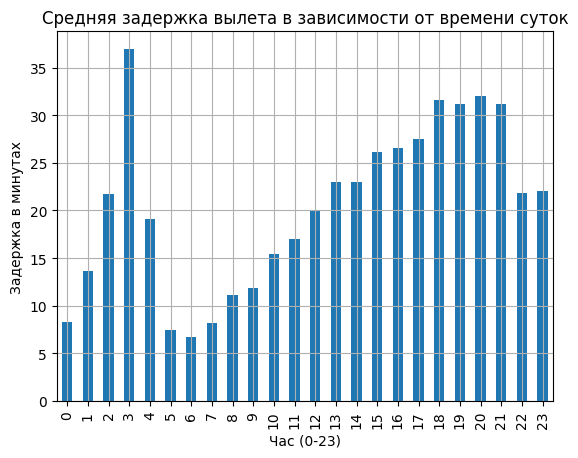

In [5]:
df['HOUR'] = df['SCHEDULED_DEPARTURE'] // 100
hourly_delay = df.groupby('HOUR')['DEPARTURE_DELAY'].mean()
hourly_delay.plot(kind = 'bar')
plt.title('Средняя задержка вылета в зависимости от времени суток')
plt.xlabel('Час (0-23)')
plt.ylabel('Задержка в минутах')
plt.grid(True)
plt.show()

Здесь можно видеть, что задержки растут к трем часам, после чего идут на спад и к вечеру растут почти линейно.

Значит можно предположить, что между 0-3 и 6-20 часами слишком плотный график полетов, из-за чего задержки "накапливаются"

Но, конечно, не может много людей лететь в 0-3 часа ночи, значит это связано с чем-то другим. Возможно из-за того, что для скорости я взял небольшой размер выборки, а полетов ночью мало, из-за чего выбросы могут все испортить. Для того, чтобы разобраться, почему растет задержка к трем часам ночи, нужно взять выборку побольше и посмотреть на другие графики, проверить медиану и тд, но это уже другая задача. Основная гипотеза о том, что к вечеру набирается "снежный ком" задержек верна.


# **Исследование 2**
Теперь я хочу посмотреть, какие аэропорты являются антилидерами в задержках прилета (рассмотрю топ-10). Это покажет, где стоит расширить полосы\терминалы\улучшить работу\может дело с аэропортами вылета, которые с ними связаны.

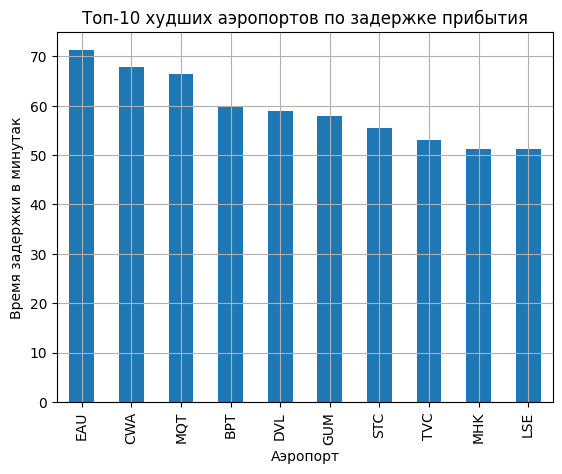

In [6]:
hourly_airport_delay = df.groupby('DESTINATION_AIRPORT')['ARRIVAL_DELAY'].mean()
hourly_airport_delay.sort_values(ascending = False, inplace = True)
hourly_airport_delay = hourly_airport_delay.head(10)
hourly_airport_delay.plot(kind = 'bar')
plt.title('Топ-10 худших аэропортов по задержке прибытия')
plt.xlabel('Аэропорт')
plt.ylabel('Время задержки в минутак')
plt.grid(True)


Можно заметить, что, вопреки ожиданиям, в топе задержек не большие аэропорты вроде Нью-Йорка или Лос-Анджелеса, а маленькие. Это связано с тем, что данные аэропорты принимают очень мало рейсов и одна задержка уже сильно влияет на среднее время задержки. Чтобы получить результаты интереснее, нужно отфильтровать мелкие аэропорты.

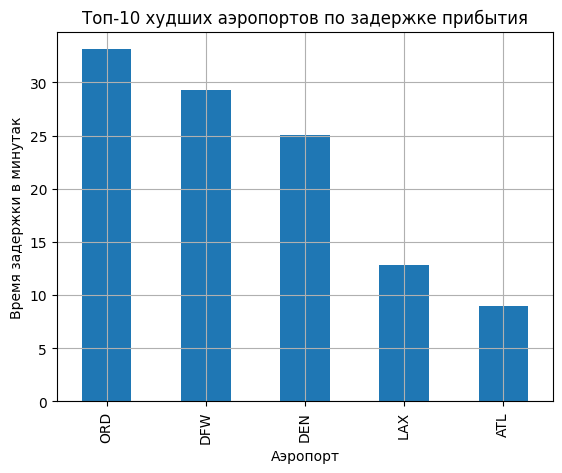

In [7]:
airport_counts = df['DESTINATION_AIRPORT'].value_counts()
large_airports = airport_counts[airport_counts > 3000].index
df_filtered = df[df['DESTINATION_AIRPORT'].isin(large_airports)]
hourly_airport_delay = df_filtered.groupby('DESTINATION_AIRPORT')['ARRIVAL_DELAY'].mean()
hourly_airport_delay.sort_values(ascending=False, inplace=True)
hourly_airport_delay = hourly_airport_delay.head(10)
hourly_airport_delay.plot(kind = 'bar')
plt.title('Топ-10 худших аэропортов по задержке прибытия')
plt.xlabel('Аэропорт')
plt.ylabel('Время задержки в минутак')
plt.grid(True)



Мы получили, что аэропортами с самой большой задержкой являются аэропорты с самой большой потоковой нагрузкой. Именно там требуется оптимизация процессов и расширение терминалов

# Исследование 3

Задержки зависят не только от инфраструктуры аэропортов, но и от того, как выстроены бизнес-процессы внутри самих авиакомпаний (скорость уборки салона, посадки пассажиров, технического обслуживания)

Как уже стало понятно, обычные столбчатые диаграммы подходят для этого не очень хорошо, так как среднее значение часто врет. Будем использовать boxplot.

В качестве анализа возьму топ 10 самых крупных авиакомпаний


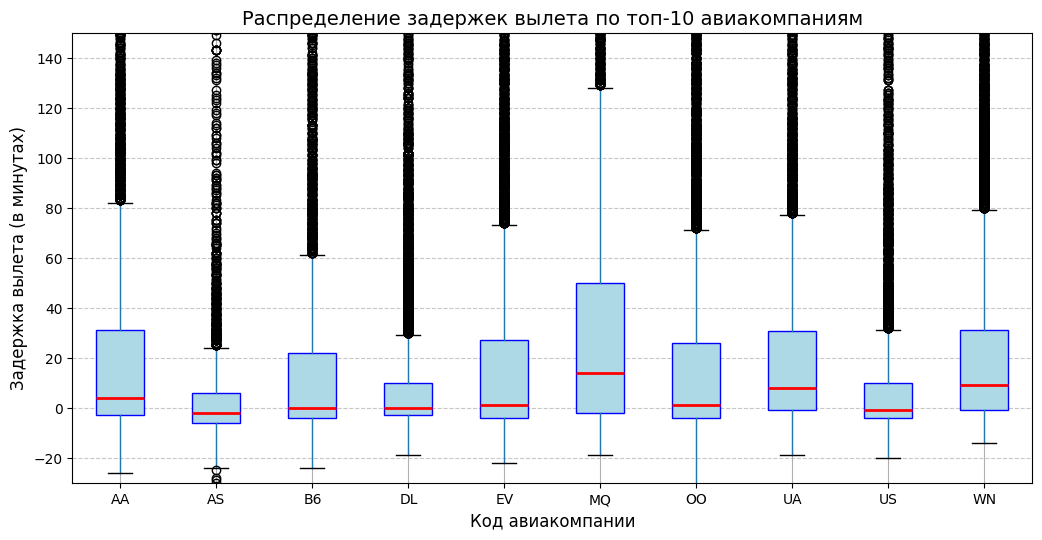

In [8]:
top_10_airlines = df['AIRLINE_x'].value_counts().nlargest(10).index
df_top_airlines = df[df['AIRLINE_x'].isin(top_10_airlines)]
fig, ax = plt.subplots(figsize=(12, 6))
df_top_airlines.boxplot(column='DEPARTURE_DELAY', by='AIRLINE_x', ax=ax,
                        patch_artist=True,
                        boxprops=dict(facecolor='lightblue', color='blue'),
                        medianprops=dict(color='red', linewidth=2))
plt.title('Распределение задержек вылета по топ-10 авиакомпаниям', fontsize=14)
plt.suptitle('')
plt.xlabel('Код авиакомпании', fontsize=12)
plt.ylabel('Задержка вылета (в минутах)', fontsize=12)

plt.ylim(-30, 150)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Из этого графика можно сделать сразу несколько важных выводов:

1) Самая плохая компания из 10 лидеров -- это MQ (Envoy Air). Она очень сильно выделяется от других компаний. У нее медиана задержки равна примерно 15 минутам, то есть ровно 50% рейсов этой компании вылетели с задержкой 15 минут или больше, причем длина бокса показывает, что компания работает криво и ее задержки непредсказуемы, а по усам можно видеть, что время задержки более 120 минут все еще считается нормой, а не выбросом.

2) Полной противоположностью MQ является компания AS (Alaska Airlines). По длине бокса видно, что она работает "как часы", так как ее время задержки горазло более предсказуемо, и, более того, как правило она вылетает даже немного раньше запланированного времени. Опоздание более, чем на 25 минут уже считается выбросом (и видно, что линия выбросов очень неплотная, что хорошо)

3) Также можно присмотреться к компаниям АА и B6. Хотя 50% рейсов у них вылетает примерно вовремя, по усам и плотным линиям выбросов видно, что они не очень хорошо справляются с форсмажерными ситуациями, так как если они задерживаются, то надолго.

# Исследование 4

Посмотрим, как разные причины влияют на задержки. Проанализируем суммарное количество минут, потерянных по каждой из пяти категорий:
1. `AIR_SYSTEM_DELAY` — задержки по вине инфраструктуры (перегрузка воздушного пространства, работа диспетчеров).
2. `SECURITY_DELAY` — задержки из-за проверок безопасности.
3. `AIRLINE_DELAY` — внутренние проблемы авиакомпаний (поломки, экипаж, посадка).
4. `LATE_AIRCRAFT_DELAY` — цепная реакция (опоздание самолета с предыдущего рейса).
5. `WEATHER_DELAY` — погодные условия.

Для такого анализа хорошо подойдет Pie Chart

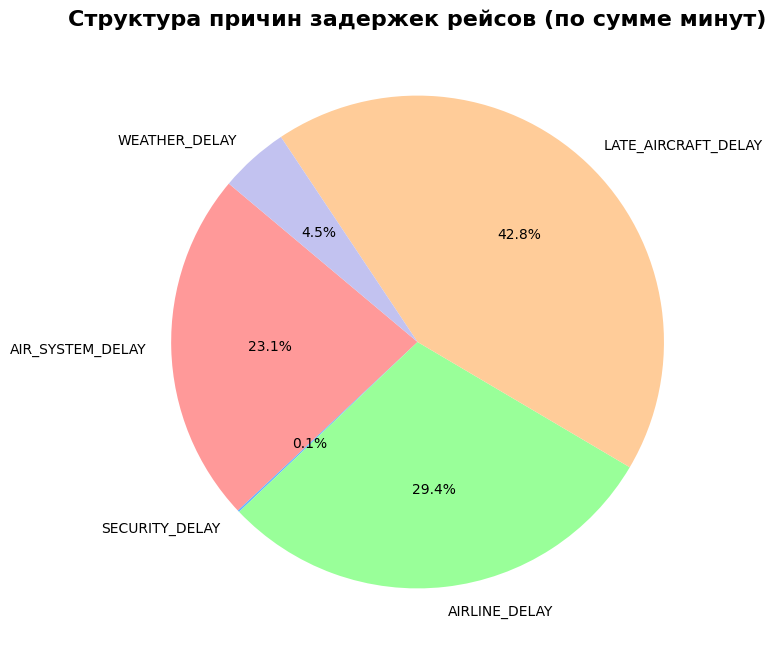

In [15]:
delay_columns = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

delays_sum = df[delay_columns].sum()

fig, ax = plt.subplots(figsize=(10, 8))

ax.pie(delays_sum,
       labels=delay_columns,
       autopct='%1.1f%%',
       startangle=140,
       colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'],
       )

plt.title('Структура причин задержек рейсов (по сумме минут)', fontsize=16, fontweight='bold')
plt.show()

Отсюда можем сделать следующие выводы:
1) Чаще всего проблема с "Цепной реакцией". Это в очередной раз подтверждает наше первое исследование: компании имеют очень плотный график без буфера и время опозданий "наслаивается" друг на друга.
2) Две других проблемы отнимают примерно одинаковое время у пассажиров: инфраструктура и внутренние проблемы с авиацией. Это то, что подлежит оптимизации
3) Как видно, по вине погоды не так уж и часто происходят задержки компаний, как может показаться изначально


# Исследование 5

Исследуем зависимость задержек от интенсивности трафика. Может быть так, что в дни пиковой нагрузки даже увеличение числа рейсов приводит к серьезным заторам. Совместим на одном графике общее количество рейсов по дням недели и среднюю задержку прилета. Это позволит увидеть, справляется ли система с нагрузкой в тяжелые дни.

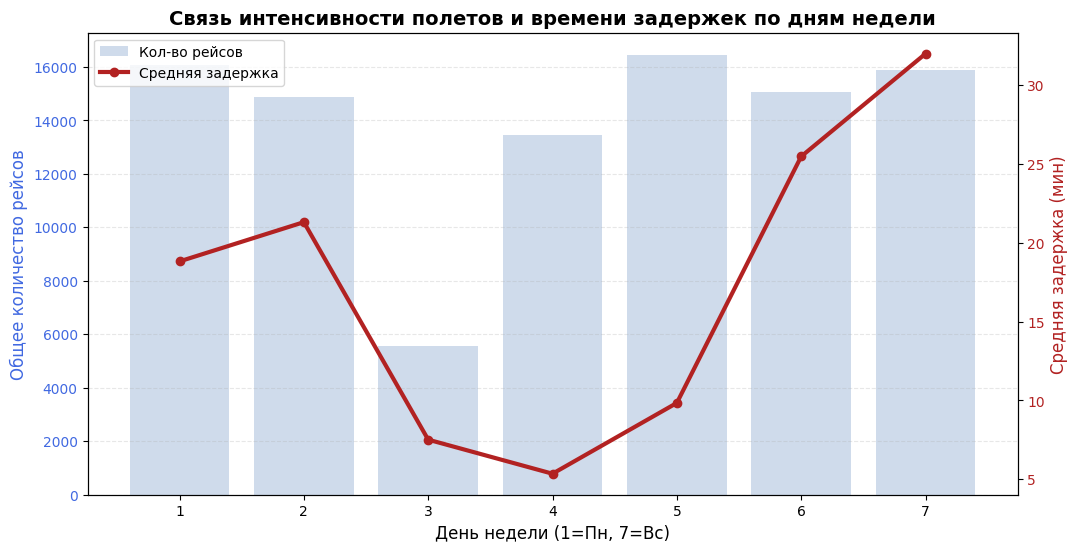

In [16]:
weekly_delays = df.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].mean()
weekly_counts = df.groupby('DAY_OF_WEEK')['ARRIVAL_DELAY'].count()

fig, ax1 = plt.subplots(figsize=(12, 6))

color_counts = 'lightsteelblue'
ax1.bar(weekly_counts.index, weekly_counts.values, color=color_counts, alpha=0.6, label='Кол-во рейсов')
ax1.set_xlabel('День недели (1=Пн, 7=Вс)', fontsize=12)
ax1.set_ylabel('Общее количество рейсов', color='royalblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='royalblue')

ax2 = ax1.twinx()
color_delay = 'firebrick'
ax2.plot(weekly_delays.index, weekly_delays.values, color=color_delay, marker='o', linewidth=3, label='Средняя задержка')
ax2.set_ylabel('Средняя задержка (мин)', color=color_delay, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_delay)

plt.title('Связь интенсивности полетов и времени задержек по дням недели', fontsize=14, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(range(1, 8))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.show()

Тут видно, что, вопреки гипотезе, задержки напрямую от трафика не зависят. Например, в пятницу, при огромной загрузке, среднее время задержки очень даже нормальное -- всего 10 минут. А вот в выходные мы видим резкий прирост задержки (причем с пятницу на субботу нагрузка даже немного падает). Это может быть связано с тем, что часть штата отдыхает, а нагрузка остается той же, что поднимает время задержки в среднем на 15-20 минут.